# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. General linear models/latent variable models/activation functions don't produce a simple linear relationship, which make it more applicable to real world sitations. In real world situations, relationships and correlations are almost never perfectly linear, so general linear models/latent variable models/activation functions give more realistic representations. General linear models still use a linear combination of inputs, but they pass it through a function so the output makes sense for the problem. 
2. Binary and categorical cross entropy are effectiv eloss functions because they directly measure how good the model’s predicted probabilities are compared to the actual outcomes. They penalize confident wrong predictions more heavily, while also aligning with the maxiumum likelihood estimation, which helps the model learn better probability estimates and make good choices for training.
3. True. Logistic regression is considered a linear model because it uses a  linear combination of the inputs, even though that output is passed through a nonlinear function. 
4. False. Logistic regression is designed for classification, since its outputs are probabilities that can be used to assign data points to different classes. 
5. No. In logistic regression, the coefficient does have anything to do with the direct change in the predicted value for a 1-unit increase in the feature.
6. False. Logistic regression does not automatically capture complex relationships, so feature engineering is need to map outputs. 
7. False. Logistic regression isn’t always better than OLS. Logistic regression better for classigication, while OLS is better for predicting continuous outcomes. 

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [14]:
# 2.1
import pandas as pd
import statsmodels.api as sm
df = pd.read_csv("data.csv", sep=";")
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]
df = df[cols]
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [16]:
# Handling missing values
df.replace(["?", "NA", "N/A", "", " "], pd.NA, inplace=True)
print(df.isnull().sum())

# there are 0 missing values but here is how i would handle them if there were any
# df.dropna(inplace=True)  # drop rows with missing values
# or
# df.fillna(df.mean(), inplace=True)  # for numerical columns
# or
# df.fillna(df.mode().iloc[0], inplace=True) # for categorical columns

df["dropout"] = df["Target"].map({
    "Dropout": 1,
    "Graduate": 0,
    "Enrolled": 0
})

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


In [23]:
# 2.2 
# Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. 
# Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

X = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = df["dropout"] 
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())

# Interpretation of results:
# Debtor and Age at enrollment have positive coefficients, meaning they are associated with a higher probability of dropout. 
# Tuition fees up to date and Scholarship holder have negative coefficients, indicating they are associated with a lower probability of dropout. 
# Being up to date on tuition has a large negative coefficient, suggesting that it strongly reduces dropout risk.

Optimization terminated successfully.
         Current function value: 0.500966
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                dropout   No. Observations:                 4424
Model:                          Logit   Df Residuals:                     4419
Method:                           MLE   Df Model:                            4
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.2020
Time:                        15:54:21   Log-Likelihood:                -2216.3
converged:                       True   LL-Null:                       -2777.3
Covariance Type:            nonrobust   LLR p-value:                1.298e-241
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.5352      0.182      2.943      0.003       0.179   

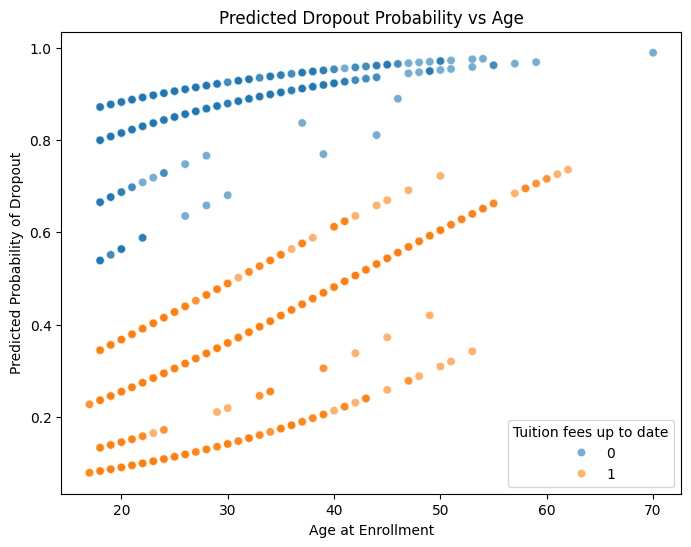

Age at enrollment
19   -0.617508
21   -0.609389
25   -0.602277
23   -0.600477
20   -0.596837
18   -0.593552
24   -0.589271
22   -0.578686
26   -0.570143
27   -0.568978
32   -0.553224
31   -0.552262
29   -0.548182
28   -0.544212
36   -0.535356
33   -0.526078
35   -0.524814
30   -0.522608
34   -0.518773
38   -0.505766
39   -0.489337
37   -0.480605
43   -0.480293
42   -0.472000
41   -0.450525
45   -0.437655
40   -0.431920
47   -0.415545
48   -0.409293
51   -0.405813
44   -0.387886
53   -0.386111
46   -0.383548
49   -0.382215
50   -0.376244
54   -0.324778
55   -0.299373
57   -0.280912
59   -0.262935
17         NaN
52         NaN
58         NaN
60         NaN
61         NaN
62         NaN
70         NaN
Name: diff, dtype: float64
19
On average, being up to date on tuition reduces the predicted probability of dropout by -0.4824.


In [33]:
# 2.3
# Use `.predict_proba` and compute expected dropout probabilities. 
# Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. 
# For what ages does being up to date on tuition seem to reduce dropout probability the most? 
# On average, by how much does being up to date on tuition change the predicted probability of dropout?

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

X = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = df["dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)
df["pred_prob"] = model.predict_proba(X)[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Age at enrollment",
    y="pred_prob",
    hue="Tuition fees up to date",
    alpha=0.6
)
plt.title("Predicted Dropout Probability vs Age")
plt.ylabel("Predicted Probability of Dropout")
plt.xlabel("Age at Enrollment")
plt.show()

# What ages does being up to date on tuition seem to reduce dropout probability the most?
age_effect = df.groupby(["Age at enrollment", "Tuition fees up to date"])["pred_prob"].mean().unstack()

# difference: (up to date - not)
age_effect["diff"] = age_effect[1] - age_effect[0]

print(age_effect["diff"].sort_values())
print(age_effect["diff"].idxmin())

# When students are around 20 years old, being up to date on tuition seems to reduce dropout probability the most, with 19 being the age where the difference is largest.

# On average, by how much does being up to date on tuition change the predicted probability of dropout?
avg_effect = age_effect["diff"].mean()
print(f"On average, being up to date on tuition reduces the predicted probability of dropout by {avg_effect:.4f}.")


In [35]:
# 2.4
# Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)
print(cm)

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)


[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


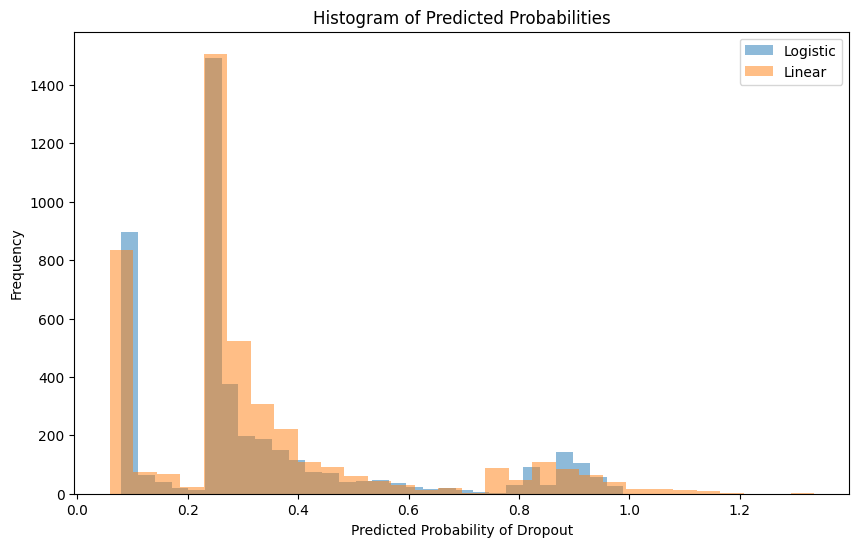

In [39]:
# 2.5

# Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. 
# Make a histogram of predicted probabilities for both logistic regression and the linear model. 
# Compare their performance.

from sklearn.linear_model import LinearRegression
X_lin = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
X_lin = sm.add_constant(X_lin)

y = df["dropout"]

linear_model = sm.OLS(y, X_lin).fit()

# Predicted probabilities (can go <0 or >1)
df["pred_prob_linear"] = linear_model.predict(X_lin)

df["pred_prob_logistic"] = model.predict_proba(X)[:, 1]

# histogram of predicted probabilities
plt.figure(figsize=(10,6))

plt.hist(df["pred_prob_logistic"], bins=30, alpha=0.5, label="Logistic")
plt.hist(df["pred_prob_linear"], bins=30, alpha=0.5, label="Linear")

plt.legend()
plt.title("Histogram of Predicted Probabilities")
plt.xlabel("Predicted Probability of Dropout")
plt.ylabel("Frequency")

plt.show()

# Comparing performance:
# The logistic regression model produces predicted probabilities that are constrained between 0 and 1, which is appropriate for classification. 
# However, the linear model produces predicted probabilities that are greater than 1, which is not meaningful in the context of probabilities. 
# The logistic model’s predictions are more concentrated and realistic, while the linear model is more dispersed. 
# Overall, logistic regression provides more appropriate probability estimates for predicting dropout.

In [ ]:
# 2.6
# Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

# Students most at risk of dropping out are those with financial strain (outstanding debt or not up to date on tuition), no scholarship support, and older age at enrollment. 
# The financial variables have the strongest impact on dropout, so interventions like tuition assistance and increased access to scholarships would likely have the biggest impact. 
# Support for students with unpaid balances could help reduce dropout rates significantly.

In [ ]:
# 2.7
# Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. 
# Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. 
# Use `.predict_proba` to predict probabilities instead and look at the values. 
# Does your hard classification predict every class? Do your predicted probabilities predict every class?

X = df[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y = df["Target"]  # now 3 classes: Dropout, Graduate, Enrolled

model_multi = LogisticRegression(max_iter=1000)
model_multi.fit(X, y)

y_pred = model_multi.predict(X)

cm = confusion_matrix(y, y_pred)
print(cm)
print(set(y_pred))

# The model collapses the problem into two classes when making hard predictions, ignoring the “Enrolled” category.

y_pred_proba = model_multi.predict_proba(X)
print(y_pred_proba[:5])  # predicted probabilities for the first 5 samples

# Does hard classification predict every class? 
# No, it only predicts "Dropout" and "Graduate", never "Enrolled".

# Do predicted probabilities predict every class?
# Yes, the predicted probabilities show non-zero probabilities for all three classes

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
{'Dropout', 'Graduate'}
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [53]:
# 3.1
# Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.


df = pd.read_csv("cirrhosis.csv")
# filtering
cols = ["Bilirubin", 
        "Edema", 
        "Drug", 
        "Stage", 
        "Status"]
df = df[cols]

# handling missing values
df.replace(["?", "NA", "N/A", "", " "], pd.NA,)
print(df.isnull().sum()) 

# filling missing values
df["Stage"] = df["Stage"].fillna(df["Stage"].median())

df["Drug"] = df["Drug"].fillna(df["Drug"].mode()[0])

# After looking for missing values, there were only missing values in the "Stage" and "Drug" columns. 
# I filled the missing values in "Stage" with the median value because it was a numerical value, and the missing values in "Drug" with the mode because it was a categorical value.

df.head()


Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [ ]:
# 3.2
# Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. 
# Does the drug improve survival probability? 
# Does higher or lower bilirubin predict a higher or lower survival rate? 
# How does survival rate vary with edema?

df["status_binary"] = df["Status"].apply(lambda x: 1 if x == "D" else 0)
df_encoded = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)

X = df_encoded[[
    "Bilirubin",
    "Edema_S",
    "Edema_Y",
    "Drug_Placebo"
]]

y = df_encoded["status_binary"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})
print(coef_df)

# Interpretation of results:

# The coefficient on Drug_Placebo is slightly negative, meaning that placebo is associated with a lower probability of death compared to the drug. 
# This implies that the drug does not improve survival probability in this model, though the effect is very small.

# Higher bilirubin levels are associated with a higher probability of death, as indicated by the positive coefficient. 
# So, higher bilirubin creates a lower survival rate, while lower bilirubin predicts a higher survival rate.

# Survival decreases as edema becomes more severe. Mild edema (Edema_S) has a higher probability of death, while severe edema (Edema_Y) has an even higher probability of death.

       Variable  Coefficient
0     Bilirubin     0.288007
1       Edema_S     0.789076
2       Edema_Y     1.713609
3  Drug_Placebo    -0.061436


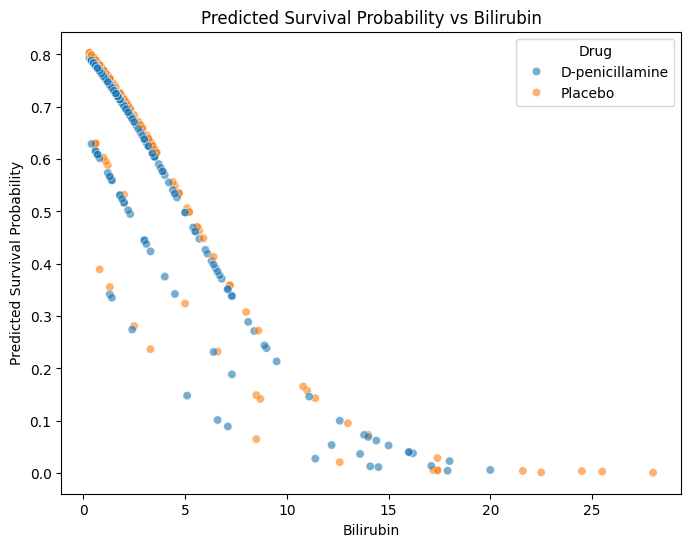

Drug
D-penicillamine    0.617629
Placebo            0.609990
Name: prob_survival, dtype: float64
Difference (drug - placebo): 0.007639046255593751


In [ ]:
# 3.3
# Use `.predict_proba` and compute expected surivival probabilities. 
# Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. 
# For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

# probability of death
df["prob_death"] = model.predict_proba(X)[:, 1]

# probability of survival
df["prob_survival"] = 1 - df["prob_death"]

# scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Bilirubin",
    y="prob_survival",
    hue="Drug",
    alpha=0.6
)

plt.title("Predicted Survival Probability vs Bilirubin")
plt.ylabel("Predicted Survival Probability")
plt.xlabel("Bilirubin")
plt.show()

avg_survival = df.groupby("Drug")["prob_survival"].mean()
print(avg_survival)

diff = avg_survival["D-penicillamine"] - avg_survival["Placebo"]
print("Difference (drug - placebo):", diff)

# For what values of Bilirubin does the drug seem to increase patient survival rate?
# The drug does not appear to really increase survival at any particular range of bilirubin values. 
# Across all levels, the survival probabilities for patients taking the drug and those on placebo are very similar,

# By how much do patients who take the drug increase their probability of survival on average?
# On average, patients taking the drug have a extrememly slightly higher predicted survival probability of about 0.008

In [59]:
# 3.4
# Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)
print(cm)
accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

[[236  21]
 [ 91  70]]
Accuracy: 0.7320574162679426


   prob_survival  prob_survival_linear
0       0.011454             -0.167527
1       0.753065              0.726171
2       0.559602              0.533003
3       0.531046              0.517281
4       0.625754              0.659308


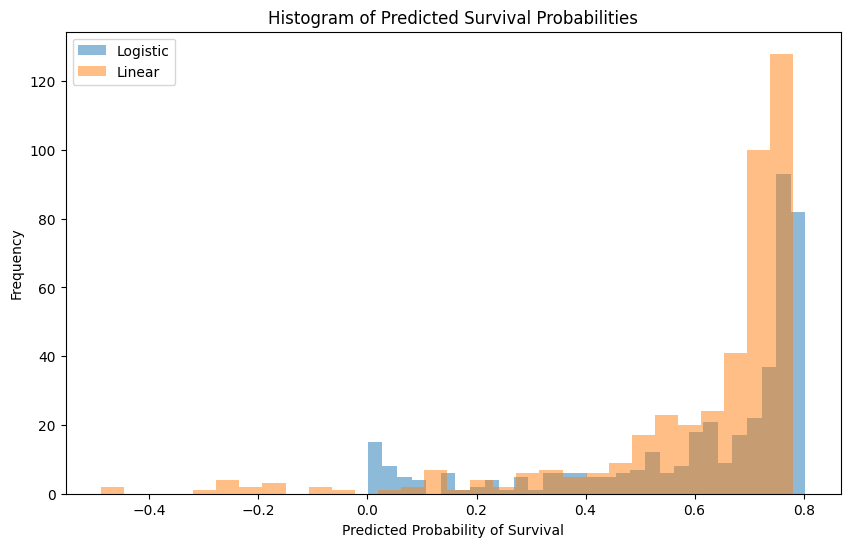

In [ ]:
# 3.5 
# Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. 
# Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

X_lin = df_encoded[[
    "Bilirubin",
    "Edema_S",
    "Edema_Y",
    "Drug_Placebo"
]].astype(float)

X_lin = sm.add_constant(X_lin)

y = df_encoded["status_binary"].astype(float)

lin_model = sm.OLS(y, X_lin).fit()

# predicted probability of death
df["prob_death_linear"] = lin_model.predict(X_lin)
# convert to survival probability
df["prob_survival_linear"] = 1 - df["prob_death_linear"]
print(df[["prob_survival", "prob_survival_linear"]].head())

# histogram of predicted probabilities
plt.figure(figsize=(10,6))
plt.hist(df["prob_survival"], bins=30, alpha=0.5, label="Logistic")
plt.hist(df["prob_survival_linear"], bins=30, alpha=0.5, label="Linear")
plt.legend()
plt.title("Histogram of Predicted Survival Probabilities")
plt.xlabel("Predicted Probability of Survival")
plt.ylabel("Frequency")
plt.show()

# Comparing performance:
# The linear model produces a wider range of values, including negative probabilities (like below 0), which are not meaningful in this context.
# From the histogram, the logistic model’s predictions are more concentrated and realistic, while the linear model is more spread out and less reliable.
# Overall, logistic regression performs better because it respects the structure of probability and gives more interpretable predictions.

In [ ]:
# 3.6
# Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. 
# Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. 
# Use `.predict_proba` to predict probabilities instead and look at the values. 
# Does your hard classification predict every class? Do your predicted probabilities predict every class? 

X = df_encoded[[
    "Bilirubin",
    "Edema_S",
    "Edema_Y"
]]

y = df_encoded["Stage"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
print(cm)

print("Predicted classes:", set(y_pred))

y_pred_proba = model.predict_proba(X)

print("First 5 probability rows:")
print(y_pred_proba[:5])

print("Classes order:", model.classes_)

# The hard classification do not predict every class. It only predicts stages 3 and 4. 
# The predicted probabilities do predict every class, as we can see from the output of predict_proba.

[[  0   0  20   1]
 [  0   0  82  10]
 [  0   0 138  23]
 [  0   0  95  49]]
Predicted classes: {np.float64(3.0), np.float64(4.0)}
First 5 probability rows:
[[4.49354917e-04 5.02696099e-02 1.38627217e-01 8.10653818e-01]
 [6.77549265e-02 2.50844396e-01 4.07512583e-01 2.73888094e-01]
 [3.96287504e-02 1.39551385e-01 3.41299566e-01 4.79520299e-01]
 [3.49932784e-02 1.37489764e-01 3.40062972e-01 4.87453986e-01]
 [3.43910468e-02 2.38995766e-01 4.14218360e-01 3.12394827e-01]]
Classes order: [1. 2. 3. 4.]


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

**4**

The coefficients of a logistic regression quantifies the relationship between each predictor variable and the log-odds of the outcome. A positive coefficient means that as the predictor variable increases, the log-odds of the outcome coming true increases which means there is a higher probability of the outcome. The opposite is true for negative coefficients. 

**4.1**

The derivative is just the coefficient b_k. So, for a 1-unit increase in x_k, the prediction ŷ changes by exactly b_k.

**4.2**

For the logistic model, the predicted probability is

$$
\hat{p}_i = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}
$$

The derivative with respect to the $k$-th feature is

$$
\frac{\partial \hat{p}_i}{\partial x_k} = b_k \hat{p}_i (1 - \hat{p}_i)
$$

Unlike the linear model, this derivative depends on $\hat{p}_i$, so it changes as $x$ changes. In the linear model, the effect is constant ($b_k$), but in logistic regression it is scaled by $\hat{p}_i (1 - \hat{p}_i)$.

The coefficient $b_k$ (up to a factor of 4) is a good approximation of the effect when $\hat{p}_i \approx 0.5$, since this is where $\hat{p}_i (1 - \hat{p}_i)$ is largest.

**4.3**

A one-unit increase in $x_k$ increases the log odds ratio by $b_k$.

This is because
$$
\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x
$$
is linear in $x$, so the derivative with respect to $x_k$ is $b_k$.
